# Analisi cyclictest
Grafici: jitter massimo per scenario, boxplot e distribuzione delle latenze, riepilogo (media/std/max/min) e jitter per thread.

In [1]:
%matplotlib ipympl

import json
from pathlib import Path
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')
pd.options.display.float_format = '{:.3f}'.format




In [2]:
# Carica tutti i file JSON e HIST disponibili
BASE_DIR = Path('.')
json_files = sorted(BASE_DIR.glob('cyclic_*.json'))
hist_files = sorted(BASE_DIR.glob('cyclic_*.hist'))
print('Trovati', len(json_files), 'file JSON e', len(hist_files), 'file HIST:')
for f in json_files:
    print(' -', f.name)
for f in hist_files:
    print(' -', f.name)


Trovati 3 file JSON e 3 file HIST:
 - cyclic_baseline_default.json
 - cyclic_stress_100k_default.json
 - cyclic_stress_1M_default.json
 - cyclic_baseline_default.hist
 - cyclic_stress_100k_default.hist
 - cyclic_stress_1M_default.hist


In [3]:
# Normalizzazione nomi scenario e label leggibili
def normalize_key(name: str) -> str:
    key = name.lower()
    key = key.replace('cyclic_', '')
    key = key.replace('stess', 'stress')
    key = key.replace('noprempt', 'nopreempt')
    key = key.replace('preemptrt', 'preempt_rt')
    key = key.replace('preempt-rt', 'preempt_rt')
    key = key.replace('nopreempt-rt', 'nopreempt_rt')
    key = key.replace('__', '_')
    return key

def extract_label(name: str) -> str:
    return normalize_key(name)

def extract_case_name(scenario_key: str) -> str:
    key = normalize_key(scenario_key)
    for prefix in ('baseline_', 'stress_100k_', 'stress_1m_'):
        if key.startswith(prefix):
            return key[len(prefix):]
    return key


In [4]:
def parse_hist_file(path: Path):
    if path is None or not path.exists():
        return {}
    text = path.read_text()
    hist_map = {}
    try:
        data = json.loads(text)
    except json.JSONDecodeError:
        data = None

    if isinstance(data, dict):
        if 'thread' in data:
            for tid_str, info in data['thread'].items():
                hist = info.get('histogram') or info.get('hist') or {}
                hist_map[int(tid_str)] = {int(k): int(v) for k, v in hist.items()}
            return hist_map
        if 'histogram' in data:
            hist = data.get('histogram') or {}
            hist_map[0] = {int(k): int(v) for k, v in hist.items()}
            return hist_map
        if all(str(k).lstrip('-').isdigit() for k in data.keys()):
            hist_map[0] = {int(k): int(v) for k, v in data.items()}
            return hist_map

    current_tid = None
    thread_re = re.compile(r'(?:thread|tid)\s*(\d+)', re.I)
    for line in text.splitlines():
        line = line.strip()
        if not line or line.startswith('#'):
            continue
        match = thread_re.search(line)
        if match:
            current_tid = int(match.group(1))
            hist_map.setdefault(current_tid, {})
            continue
        parts = line.split()
        if len(parts) >= 2 and parts[0].lstrip('-').isdigit() and parts[1].lstrip('-').isdigit():
            lat = int(parts[0])
            cnt = int(parts[1])
            if current_tid is None:
                current_tid = 0
                hist_map.setdefault(current_tid, {})
            hist_map[current_tid][lat] = cnt
    return hist_map


def hist_to_array(hist):
    lats = []
    for lat, cnt in hist.items():
        lats.extend([lat] * cnt)
    return np.array(lats, dtype=int)


def load_hist_only(hist_map, scenario_key: str, scenario_label: str, case_name: str):
    thread_rows, lat_rows = [], []
    for tid, hist in hist_map.items():
        arr = hist_to_array(hist)
        if arr.size:
            mean = float(arr.mean())
            std = float(arr.std())
            tmin = int(arr.min())
            tmax = int(arr.max())
            samples = int(arr.size)
            lat_rows.extend([(scenario_label, tid, int(v), scenario_key, case_name) for v in arr])
        else:
            mean = float('nan')
            std = float('nan')
            tmin = float('nan')
            tmax = float('nan')
            samples = 0
        thread_rows.append({
            'scenario_key': scenario_key,
            'scenario_label': scenario_label,
            'case_name': case_name,
            'thread': tid,
            'min': tmin,
            'max': tmax,
            'mean': mean,
            'std': std,
            'samples': samples,
            'jitter': tmax - tmin if tmin == tmin and tmax == tmax else np.nan,
        })
    return thread_rows, lat_rows


def load_json_hist(path: Path, hist_map: dict, scenario_key: str, scenario_label: str, case_name: str):
    data = json.loads(path.read_text()) if path else {}
    threads = data.get('thread', {})
    thread_rows, lat_rows = [], []

    if threads:
        items = [(int(tid_str), info) for tid_str, info in threads.items()]
    else:
        items = [(tid, {}) for tid in sorted(hist_map.keys())]

    for tid, info in items:
        hist = hist_map.get(tid)
        if hist is None:
            hist = {int(k): int(v) for k, v in (info.get('histogram') or {}).items()}
        arr = hist_to_array(hist)
        if arr.size:
            mean = float(arr.mean())
            std = float(arr.std())
            tmin = int(arr.min())
            tmax = int(arr.max())
            samples = int(arr.size)
            lat_rows.extend([(scenario_label, tid, int(v), scenario_key, case_name) for v in arr])
        else:
            mean = float(info.get('avg', np.nan))
            std = float('nan')
            tmin = int(info.get('min', np.nan)) if info.get('min') is not None else np.nan
            tmax = int(info.get('max', np.nan)) if info.get('max') is not None else np.nan
            samples = int(info.get('cycles', 0))
        thread_rows.append({
            'scenario_key': scenario_key,
            'scenario_label': scenario_label,
            'case_name': case_name,
            'thread': tid,
            'min': tmin,
            'max': tmax,
            'mean': mean,
            'std': std,
            'samples': samples,
            'jitter': tmax - tmin if tmin == tmin and tmax == tmax else np.nan,
        })
    return thread_rows, lat_rows


In [5]:
# Costruzione DataFrame
thread_rows = []
latency_rows = []

json_by_stem = {p.stem: p for p in json_files}
hist_by_stem = {p.stem: p for p in hist_files}
all_stems = sorted(set(json_by_stem) | set(hist_by_stem))

for stem in all_stems:
    json_path = json_by_stem.get(stem)
    hist_path = hist_by_stem.get(stem)

    raw_key = stem.replace('cyclic_', '')
    scenario_key = normalize_key(raw_key)
    scenario_label = extract_label(raw_key)
    case_name = extract_case_name(raw_key)

    hist_map = parse_hist_file(hist_path) if hist_path else {}
    if json_path:
        trows, lrows = load_json_hist(json_path, hist_map, scenario_key, scenario_label, case_name)
    else:
        trows, lrows = load_hist_only(hist_map, scenario_key, scenario_label, case_name)

    thread_rows.extend(trows)
    latency_rows.extend(lrows)

thread_df = pd.DataFrame(thread_rows)
latency_df = pd.DataFrame(latency_rows, columns=['scenario_label', 'thread', 'latency', 'scenario_key', 'case_name'])

print('Scenari trovati:', sorted(thread_df.scenario_key.unique()))
print('Totale scenari:', thread_df.scenario_key.nunique())


Scenari trovati: ['baseline_default', 'stress_100k_default', 'stress_1m_default']
Totale scenari: 3


In [6]:
# Riassunto per scenario basato sulle latenze raw
if latency_df.empty:
    summary_df = pd.DataFrame()
else:
    summary_df = (latency_df
        .groupby('scenario_key')
        .agg(mean=('latency', 'mean'),
             std=('latency', 'std'),
             min=('latency', 'min'),
             max=('latency', 'max'),
             samples=('latency', 'size'))
        .reset_index()
    )
    summary_df['jitter'] = summary_df['max'] - summary_df['min']

    label_map = (thread_df[['scenario_key','scenario_label']]
        .drop_duplicates()
        .set_index('scenario_key')['scenario_label']
    )
    summary_df['scenario_label'] = summary_df['scenario_key'].map(label_map)

summary_df


,scenario_key,mean,std,min,max,samples,jitter,scenario_label
0,baseline_default,8.718,1.129,5,33,119994,28,baseline_default
1,stress_100k_default,9.456,2.211,5,39,119984,34,stress_100k_default
2,stress_1m_default,7.693,1.235,6,78,119957,72,stress_1m_default


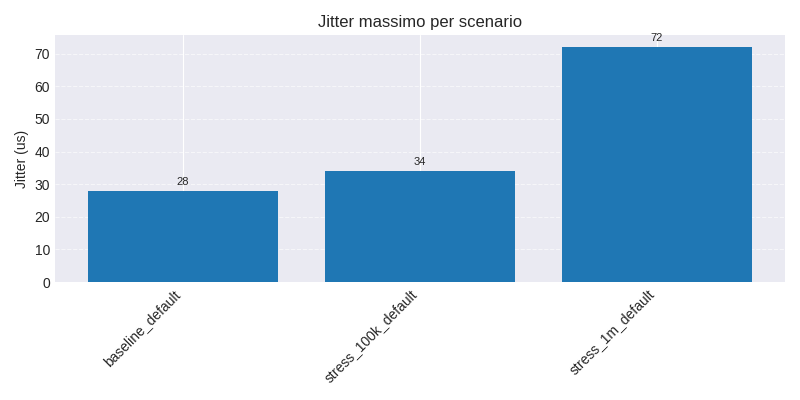

In [7]:
# Jitter massimo per scenario (colori per nome caso)
if summary_df.empty:
    print('Nessun dato disponibile per il jitter')
else:
    label_map = (thread_df[['scenario_key','scenario_label']]
        .drop_duplicates()
        .set_index('scenario_key')['scenario_label']
    )
    case_map = (thread_df[['scenario_key','case_name']]
        .drop_duplicates()
        .set_index('scenario_key')['case_name']
    )
    cases = list(dict.fromkeys(case_map.values))
    palette = list(plt.get_cmap('tab10').colors) + list(plt.get_cmap('Set2').colors)
    case_colors = {c: palette[i % len(palette)] for i, c in enumerate(cases)}

    def color_for(key):
        return case_colors.get(case_map.get(key, ''), palette[0])

    colors = [color_for(k) for k in summary_df['scenario_key']]

    fig, ax = plt.subplots(figsize=(8, 4))
    x = np.arange(len(summary_df))
    bars = ax.bar(x, summary_df['jitter'], color=colors)
    ax.set_ylabel('Jitter (us)')
    ax.set_title('Jitter massimo per scenario')
    ax.grid(True, axis='y', linestyle='--', alpha=0.6)
    ax.set_xticks(x)
    ax.set_xticklabels([label_map.get(k, k) for k in summary_df['scenario_key']], rotation=45, ha='right')
    ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
    plt.tight_layout()
    plt.show()


/tmp/ipykernel_9701/62803858.py:31: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=labels, patch_artist=True)


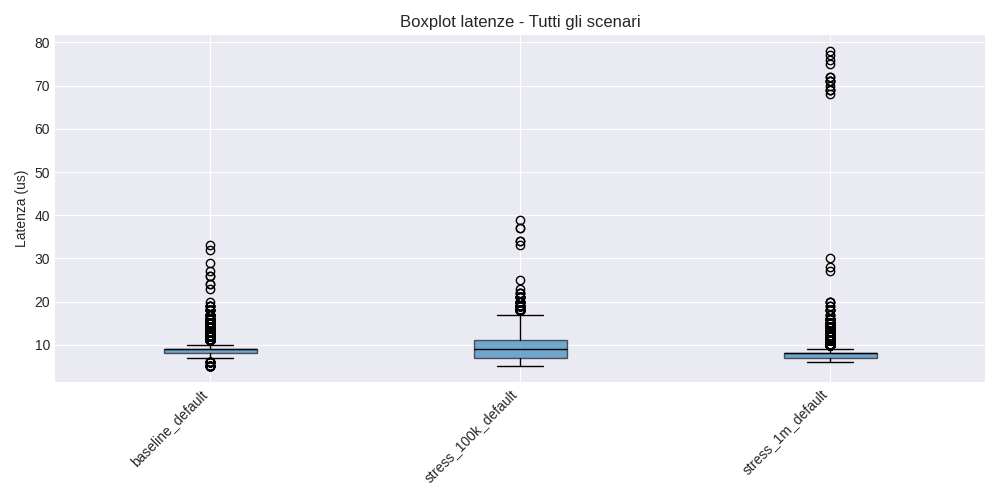

In [8]:
# Boxplot delle latenze separati: No Preempt-RT vs Preempt-RT (colori per nome caso)
if latency_df.empty:
    print('Nessuna latenza disponibile per i boxplot')
else:
    label_map = (thread_df[['scenario_key','scenario_label']]
        .drop_duplicates()
        .set_index('scenario_key')['scenario_label']
    )
    case_map = (thread_df[['scenario_key','case_name']]
        .drop_duplicates()
        .set_index('scenario_key')['case_name']
    )
    cases = list(dict.fromkeys(case_map.values))
    palette = list(plt.get_cmap('tab10').colors) + list(plt.get_cmap('Set2').colors)
    case_colors = {c: palette[i % len(palette)] for i, c in enumerate(cases)}

    def color_for(key):
        return case_colors.get(case_map.get(key, ''), palette[0])

    def plot_group(keys, title):
        if len(keys) == 0:
            print(f'Nessun scenario per {title}')
            return
        subset = latency_df[latency_df['scenario_key'].isin(keys)]
        ordered = subset['scenario_key'].unique()
        data = [subset[subset['scenario_key']==sc]['latency'] for sc in ordered]
        colors = [color_for(sc) for sc in ordered]
        labels = [label_map.get(sc, sc) for sc in ordered]

        fig, ax = plt.subplots(figsize=(10, 5))
        bp = ax.boxplot(data, labels=labels, patch_artist=True)
        for patch, c in zip(bp['boxes'], colors):
            patch.set_facecolor(c)
            patch.set_alpha(0.6)
        for median in bp['medians']:
            median.set_color('black')
        ax.set_ylabel('Latenza (us)')
        ax.set_title(title)
        plt.xticks(rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    plot_group(label_map.index, 'Boxplot latenze - Tutti gli scenari')


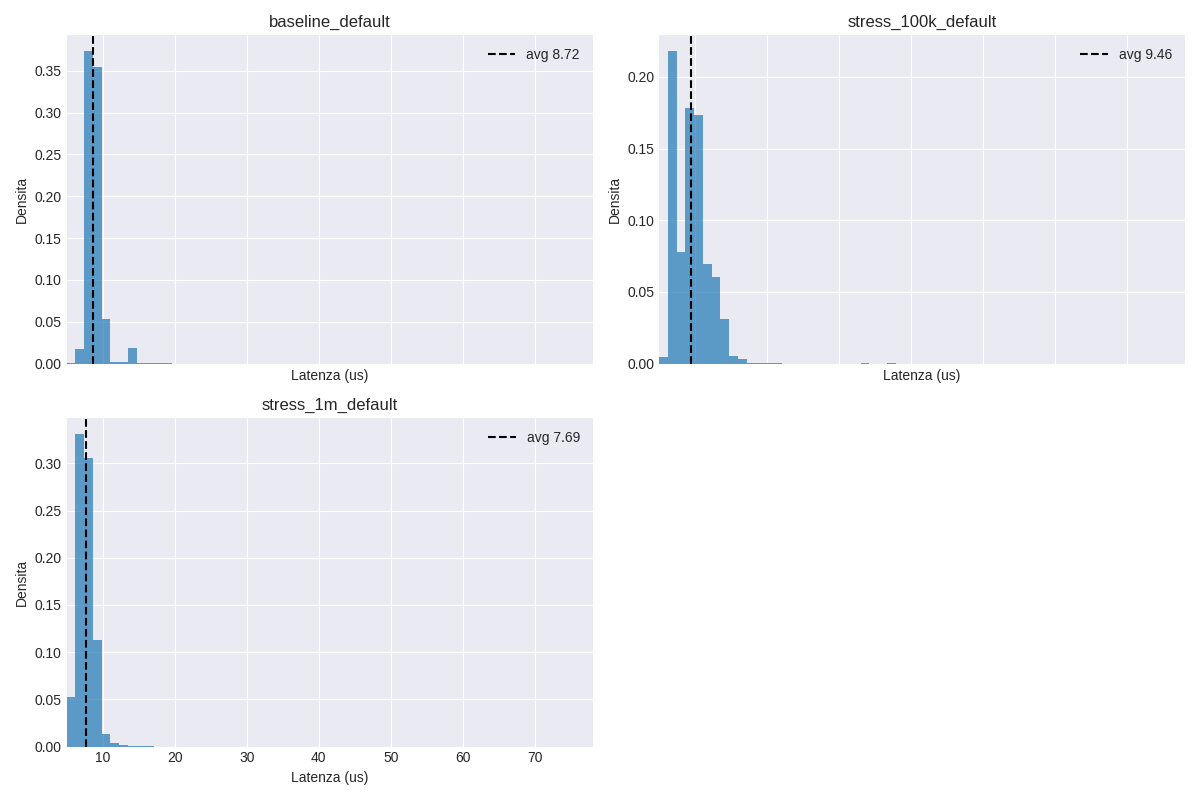

In [9]:
# Distribuzione delle latenze per scenario (colori per nome caso, stessa scala X per confronto)
if latency_df.empty:
    print('Nessuna latenza disponibile per le distribuzioni')
else:
    label_map = (thread_df[['scenario_key','scenario_label']]
        .drop_duplicates()
        .set_index('scenario_key')['scenario_label']
    )
    case_map = (thread_df[['scenario_key','case_name']]
        .drop_duplicates()
        .set_index('scenario_key')['case_name']
    )
    cases = list(dict.fromkeys(case_map.values))
    palette = list(plt.get_cmap('tab10').colors) + list(plt.get_cmap('Set2').colors)
    case_colors = {c: palette[i % len(palette)] for i, c in enumerate(cases)}

    def color_for(key):
        return case_colors.get(case_map.get(key, ''), palette[0])

    scenarios = latency_df['scenario_key'].unique()
    global_min = latency_df['latency'].min()
    global_max = latency_df['latency'].max()
    bins = np.linspace(global_min, global_max, 61)  # 60 intervalli comuni a tutti

    n = len(scenarios)
    cols = 2
    rows = (n + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols, figsize=(12, 4 * rows), sharex=True)
    axes = axes.flat if n > 1 else [axes]
    for ax, sc in zip(axes, scenarios):
        data = latency_df[latency_df.scenario_key == sc].latency
        color = color_for(sc)
        label = label_map.get(sc, sc)
        ax.hist(data, bins=bins, density=True, alpha=0.7, color=color)
        ax.axvline(data.mean(), color='black', linestyle='--', label=f"avg {data.mean():.2f}")
        ax.set_title(label)
        ax.set_xlabel('Latenza (us)')
        ax.set_ylabel('Densita')
        ax.set_xlim(global_min, global_max)
        ax.legend()
    for ax in axes[n:]:
        ax.set_visible(False)
    plt.tight_layout()
    plt.show()


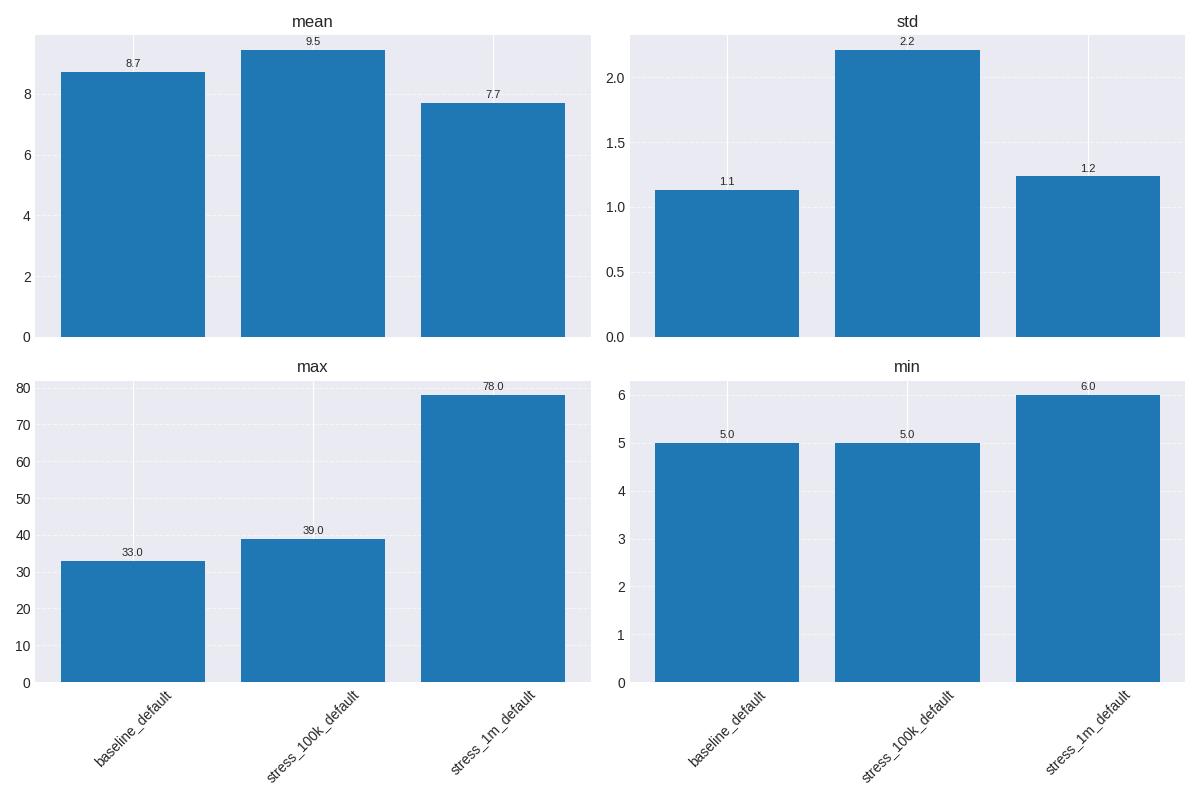

In [10]:
# Grafico riassuntivo: media, deviazione standard, max, min (colori per nome caso)
if summary_df.empty:
    print('Nessun dato disponibile per il grafico riassuntivo')
else:
    label_map = (thread_df[['scenario_key','scenario_label']]
        .drop_duplicates()
        .set_index('scenario_key')['scenario_label']
    )
    case_map = (thread_df[['scenario_key','case_name']]
        .drop_duplicates()
        .set_index('scenario_key')['case_name']
    )
    cases = list(dict.fromkeys(case_map.values))
    palette = list(plt.get_cmap('tab10').colors) + list(plt.get_cmap('Set2').colors)
    case_colors = {c: palette[i % len(palette)] for i, c in enumerate(cases)}

    def color_for(key):
        return case_colors.get(case_map.get(key, ''), palette[0])

    colors = [color_for(sc) for sc in summary_df['scenario_key']]

    fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
    metrics = ['mean', 'std', 'max', 'min']
    x = np.arange(len(summary_df))
    for metric, ax in zip(metrics, axes.flat):
        bars = ax.bar(x, summary_df[metric], color=colors)
        ax.bar_label(bars, fmt='%.1f', padding=2, fontsize=8)
        ax.set_title(metric)
        ax.grid(True, axis='y', linestyle='--', alpha=0.6)
        ax.set_xticks(x)
        ax.set_xticklabels([label_map.get(k, k) for k in summary_df['scenario_key']], rotation=45)
    plt.tight_layout()
    plt.show()


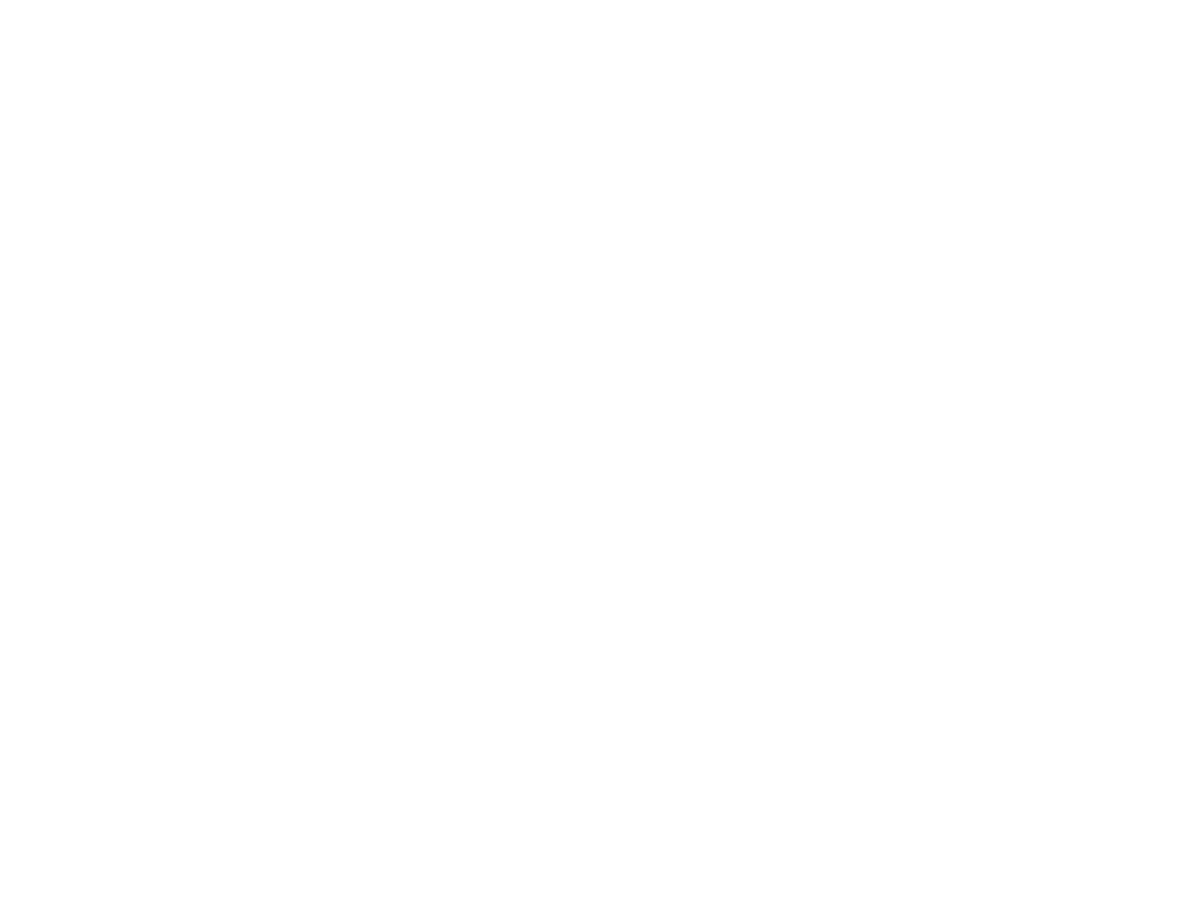

In [11]:
# Jitter per thread in ogni scenario (coppie affiancate: No Preempt-RT a sinistra, Preempt-RT a destra)
if thread_df.empty:
    print('Nessun dato thread disponibile')
else:
    label_key_df = thread_df[['scenario_label','scenario_key','case_name']].drop_duplicates()
    cases = list(dict.fromkeys(label_key_df['case_name']))
    palette = list(plt.get_cmap('tab10').colors) + list(plt.get_cmap('Set2').colors)
    case_colors = {c: palette[i % len(palette)] for i, c in enumerate(cases)}

    pairs = {}
    for _, row in label_key_df.iterrows():
        label = row['scenario_label']
        key = row['scenario_key']
        case_name = row['case_name']
        if key.endswith('_nopreempt_rt'):
            base = key.replace('_nopreempt_rt', '')
            pairs.setdefault(base, {})['nopre'] = (label, key, case_name)
        elif key.endswith('_preempt_rt'):
            base = key.replace('_preempt_rt', '')
            pairs.setdefault(base, {})['pre'] = (label, key, case_name)
        else:
            pairs.setdefault(key, {})['other'] = (label, key, case_name)

    ordered_bases = list(pairs.keys())

    fig, axes = plt.subplots(len(ordered_bases), 2, figsize=(12, 3 * len(ordered_bases)), sharey='row', squeeze=False)

    for row_idx, base in enumerate(ordered_bases):
        for col_idx, kind in enumerate(['nopre', 'pre']):
            ax = axes[row_idx, col_idx]
            entry = pairs[base].get(kind)
            if entry is None:
                ax.axis('off')
                continue
            label, key, case_name = entry
            tsub = thread_df[thread_df['scenario_key'] == key]
            color = case_colors.get(case_name, palette[0])
            bars = ax.bar(tsub['thread'], tsub['jitter'], color=color)
            ax.bar_label(bars, fmt='%.0f', padding=3, fontsize=8)
            title_suffix = 'No Preempt-RT' if kind=='nopre' else 'Preempt-RT'
            ax.set_title(f'{label} ({title_suffix})')
            ax.set_ylabel('Jitter (us)')
            ax.set_xlabel('Thread')
            ax.grid(True, axis='y', linestyle='--', alpha=0.6)

    plt.tight_layout()
    plt.show()
